# Starbucks Calorie Prediction
This project analyzes Starbucks menu data and predicts calories using machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
We load the dataset to begin analysis.

In [2]:
dm = pd.read_csv(r"C:\Users\yamala\Documents\GitHub\starbucks-calorie-prediction\data\drinkMenu_expanded.csv")
dm.head()

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0%,0%,0%,0%,175
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0%,0%,0%,0%,260
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,0%,0%,330
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,2%,0%,410
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10%,0%,20%,0%,75


In [3]:
nd = pd.read_csv(r"C:\Users\yamala\Documents\GitHub\starbucks-calorie-prediction\data\menu-nutrition-drinks.csv")
nd.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-
2,Pink Drink,-,-,-,-,-,-
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10


In [4]:
snf = pd.read_csv(r"C:\Users\yamala\Documents\GitHub\starbucks-calorie-prediction\data\menu-nutrition-food.csv", encoding = 'UTF - 16')
snf.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein (g)
0,Chonga Bagel,300,5.0,50,3,12
1,8-Grain Roll,380,6.0,70,7,10
2,Almond Croissant,410,22.0,45,3,10
3,Apple Fritter,460,23.0,56,2,7
4,Banana Nut Bread,420,22.0,52,2,6


## Exploratory Data Analysis
We explore data distribution and relationships between features.

In [5]:
dm.info()

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Beverage_category          242 non-null    str    
 1   Beverage                   242 non-null    str    
 2   Beverage_prep              242 non-null    str    
 3   Calories                   242 non-null    int64  
 4    Total Fat (g)             242 non-null    str    
 5   Trans Fat (g)              242 non-null    float64
 6   Saturated Fat (g)          242 non-null    float64
 7    Sodium (mg)               242 non-null    int64  
 8    Total Carbohydrates (g)   242 non-null    int64  
 9   Cholesterol (mg)           242 non-null    int64  
 10   Dietary Fibre (g)         242 non-null    int64  
 11   Sugars (g)                242 non-null    int64  
 12   Protein (g)               242 non-null    float64
 13  Vitamin A (% DV)           242 non-null    str    
 14  Vitam

In [6]:
dm.columns

Index(['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories',
       ' Total Fat (g)', 'Trans Fat (g) ', 'Saturated Fat (g)', ' Sodium (mg)',
       ' Total Carbohydrates (g) ', 'Cholesterol (mg)', ' Dietary Fibre (g)',
       ' Sugars (g)', ' Protein (g) ', 'Vitamin A (% DV) ', 'Vitamin C (% DV)',
       ' Calcium (% DV) ', 'Iron (% DV) ', 'Caffeine (mg)'],
      dtype='str')

In [7]:
dm.columns = dm.columns.str.strip()

In [8]:
nd.columns = nd.columns.str.strip()

In [9]:
snf.columns = snf.columns.str.strip()

In [10]:
nd

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-
2,Pink Drink,-,-,-,-,-,-
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
...,...,...,...,...,...,...,...
172,Chocolate Smoothie,320,5,53,8,20,170
173,Strawberry Smoothie,300,2,60,7,16,130
174,Ginger Ale,-,-,-,-,-,-
175,Lemon Ale,-,-,-,-,-,-


In [11]:
nd.rename(columns = {'Unnamed: 0' : 'Beverages'}, inplace = True)

In [12]:
nd.replace('-', pd.NA , inplace = True)

,Beverages,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,NaN,NaN,NaN,NaN,NaN,NaN
2,Pink Drink,NaN,NaN,NaN,NaN,NaN,NaN
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
...,...,...,...,...,...,...,...
172,Chocolate Smoothie,320,5,53,8,20,170
173,Strawberry Smoothie,300,2,60,7,16,130
174,Ginger Ale,NaN,NaN,NaN,NaN,NaN,NaN
175,Lemon Ale,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
nd = nd.dropna()

In [14]:
snf

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein (g)
0,Chonga Bagel,300,5.0,50,3,12
1,8-Grain Roll,380,6.0,70,7,10
2,Almond Croissant,410,22.0,45,3,10
3,Apple Fritter,460,23.0,56,2,7
4,Banana Nut Bread,420,22.0,52,2,6
...,...,...,...,...,...,...
108,Justin's Chocolate Hazelnut Butter,180,14.0,12,3,4
109,Justin's Classic Almond Butter,190,18.0,6,3,7
110,Lemon Chiffon Yogurt,340,13.0,38,0,18
111,Organic Avocado (Spread),90,8.0,5,4,1


In [15]:
snf.rename(columns = {'Unnamed: 0' : 'Item'} , inplace = True)

In [16]:
dm.info()

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Beverage_category        242 non-null    str    
 1   Beverage                 242 non-null    str    
 2   Beverage_prep            242 non-null    str    
 3   Calories                 242 non-null    int64  
 4   Total Fat (g)            242 non-null    str    
 5   Trans Fat (g)            242 non-null    float64
 6   Saturated Fat (g)        242 non-null    float64
 7   Sodium (mg)              242 non-null    int64  
 8   Total Carbohydrates (g)  242 non-null    int64  
 9   Cholesterol (mg)         242 non-null    int64  
 10  Dietary Fibre (g)        242 non-null    int64  
 11  Sugars (g)               242 non-null    int64  
 12  Protein (g)              242 non-null    float64
 13  Vitamin A (% DV)         242 non-null    str    
 14  Vitamin C (% DV)         242 non-null

In [17]:
nd.info()

<class 'pandas.DataFrame'>
Index: 92 entries, 0 to 173
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Beverages  92 non-null     str  
 1   Calories   92 non-null     str  
 2   Fat (g)    92 non-null     str  
 3   Carb. (g)  92 non-null     str  
 4   Fiber (g)  92 non-null     str  
 5   Protein    92 non-null     str  
 6   Sodium     92 non-null     str  
dtypes: str(7)
memory usage: 5.8 KB


In [18]:
snf.info()

<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Item         113 non-null    str    
 1   Calories     113 non-null    int64  
 2   Fat (g)      113 non-null    float64
 3   Carb. (g)    113 non-null    int64  
 4   Fiber (g)    113 non-null    int64  
 5   Protein (g)  113 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 5.4 KB


In [19]:
dm.isnull().sum()

Beverage_category          0
Beverage                   0
Beverage_prep              0
Calories                   0
Total Fat (g)              0
Trans Fat (g)              0
Saturated Fat (g)          0
Sodium (mg)                0
Total Carbohydrates (g)    0
Cholesterol (mg)           0
Dietary Fibre (g)          0
Sugars (g)                 0
Protein (g)                0
Vitamin A (% DV)           0
Vitamin C (% DV)           0
Calcium (% DV)             0
Iron (% DV)                0
Caffeine (mg)              1
dtype: int64

In [20]:
nd.isnull().sum()

Beverages    0
Calories     0
Fat (g)      0
Carb. (g)    0
Fiber (g)    0
Protein      0
Sodium       0
dtype: int64

In [21]:
snf.isnull().sum()

Item           0
Calories       0
Fat (g)        0
Carb. (g)      0
Fiber (g)      0
Protein (g)    0
dtype: int64

In [22]:
df = dm.copy()

In [23]:
df.columns = df.columns.str.strip()

## Data Visualization
We analyze how calories are distributed.

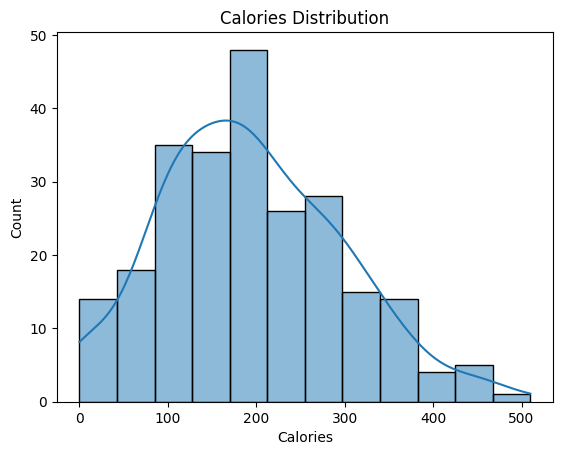

In [25]:
sns.histplot(df['Calories'], kde = True)
plt.title("Calories Distribution")
plt.show()

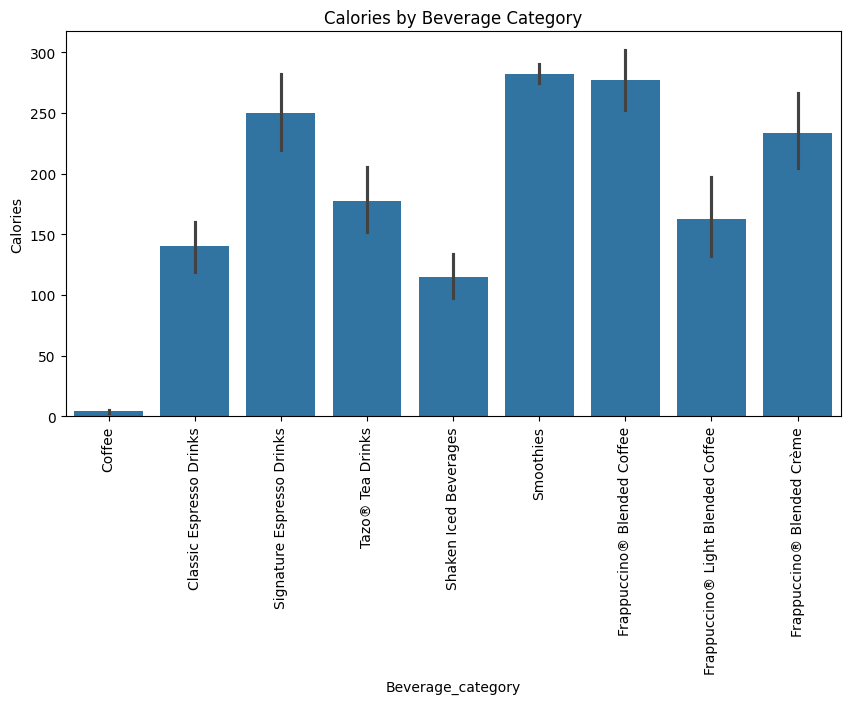

In [27]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'Beverage_category' , y = 'Calories', data = df)
plt.xticks(rotation = 90)
plt.title("Calories by Beverage Category")
plt.show()

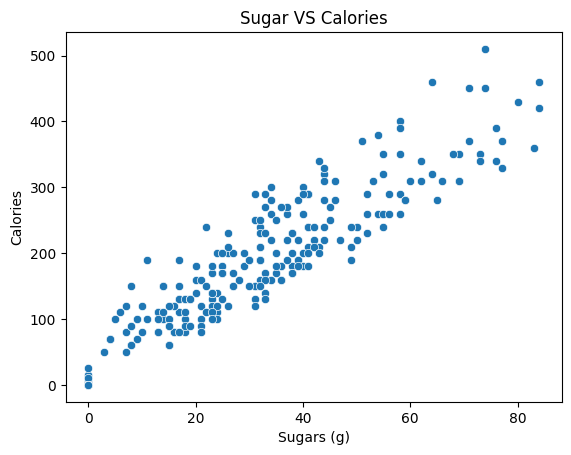

In [29]:
sns.scatterplot(x = 'Sugars (g)', y = 'Calories', data = df)
plt.title('Sugar VS Calories')
plt.show()

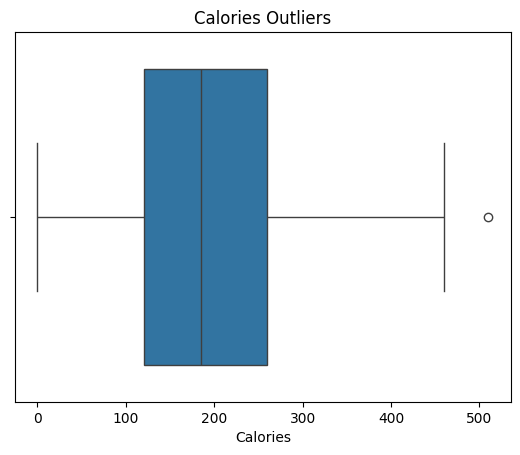

In [30]:
sns.boxplot(x = df['Calories'])
plt.title('Calories Outliers')
plt.show()

In [34]:
df['Total Fat (g)'].unique

<bound method Series.unique of 0      0.1
1      0.1
2      0.1
3      0.1
4      0.1
      ... 
237    3 2
238    0.1
239    3.5
240    1.5
241    0.1
Name: Total Fat (g), Length: 242, dtype: str>

In [35]:
df['Total Fat (g)'] = df['Total Fat (g)'].str.replace(' ','.')

In [36]:
df['Total Fat (g)'] = pd.to_numeric(df['Total Fat (g)'])

## Feature Engineering

We created new features to better capture relationships between nutritional values:

- **calorie_per_fat** = Calories / (Total Fat + 1)  
- **sugar_to_calorie_ratio** = Sugars / (Calories + 1)  
- **protein_density** = Protein / (Calories + 1)  

These features help the model understand how calories relate to fat, sugar, and protein content.  
Adding `+1` avoids division by zero.

In [37]:
df['Calorie_per_fat'] = df['Calories']/ (df['Total Fat (g)'] + 1)

In [38]:
df['Sugar_to_calorie_ratio'] = df['Sugars (g)']/ (df['Calories'] + 1)

In [39]:
df['Protien_denasity'] = df['Protein (g)']/(df['Calories'] + 1)

## Preparing Data

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
features = ['Total Fat (g)', 'Sugars (g)', 'Protein (g)', 'Total Carbohydrates (g)']
x = df[features]
y = df['Calories']

## Model Training
We train a Linear Regression model to predict calories.

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
y_pred = model.predict(x_test)
print("Predictions: ", y_pred[:5])
print("Actual Values: ", y_test[:5])

Predictions:  [222.6315629   63.70862023 243.24860613 239.71385168 309.0042804 ]
Actual Values:  24     230
6       70
152    230
209    240
237    320
Name: Calories, dtype: int64


In [61]:
from sklearn.metrics import mean_squared_error, r2_score

## Results
We evaluate model performance using Mean Squared Error and R2 Score.

In [62]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score", r2_score(y_test, y_pred))

MSE: 89.61116748576453
R2 Score 0.9877589287385887


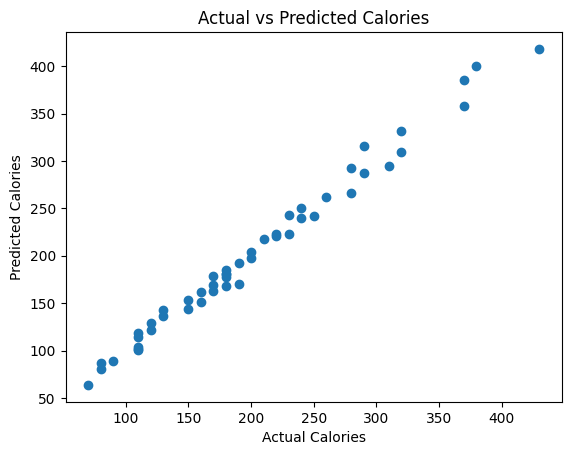

In [63]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories')
plt.show()

## Random Forest Regression

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
print("RF R2 Score: ", r2_score(y_test, rf_pred))

RF R2 Score:  0.960404622173009


## Feature Importance

Feature importance shows how much each feature contributes to the model’s predictions.

In this project, it helps identify which nutritional factors (like fat, sugar, and protein) have the most impact on calorie prediction.

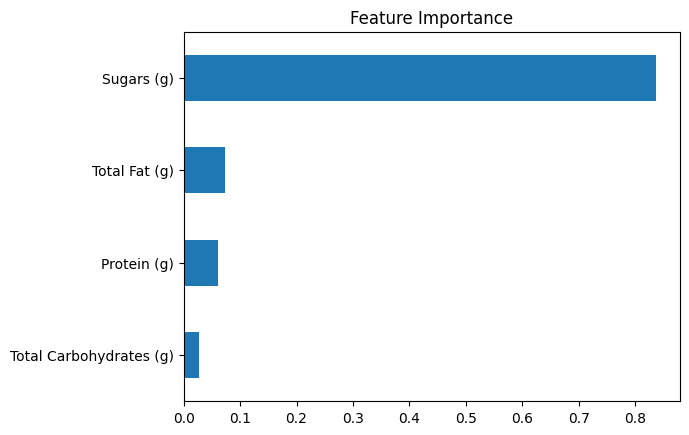

In [67]:
importance = pd.Series(rf.feature_importances_, index = features)
importance.sort_values().plot(kind = 'barh')
plt.title("Feature Importance")
plt.show()

### Observation

The model relies more heavily on certain nutritional components, indicating that calorie content is more strongly driven by specific macronutrients.
